# Pytesseract Model Demo

This notebook reproduces the `pt_model` pipeline from `models.ipynb` with short explanations before each step.

## 1) Imports and setup

Load the preprocessor, OCR detector, and helper utilities used by the PT pipeline.

In [1]:
import random
import os
import json
import re
from pathlib import Path

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from scripts.preprocess import InvoiceImagePreprocessor
from scripts.pt_model import PytesseractInvoiceTextDetector
from scripts.eval_utils import normalize_money
from scripts.visualize_util import create_analysis_dashboard, visualize_sample_results

## 2) Load ground truth labels

These are used for evaluation after OCR extraction.

In [2]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
print(ground_truth_df.columns)
ground_truth_df.head()

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth'],
      dtype='str')


,File Name,OCRed Text,batch_csv,client_name,seller_name,invoice_number,invoice_date,due_date,tax,total_amount,net_worth
0,batch1-0494.jpg,Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,Clark-Foster,Nguyen-Roach,84652373,2021-02-23,NaN,21.18,232.95,211.77
1,batch1-0489.jpg,Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"Williams, Schneider and Gomez",Scott-Howard,37451664,2020-06-11,NaN,13.99,153.92,139.93
2,batch1-0499.jpg,Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,Hester Inc,"Bailey, Murray and Lewis",40108666,2020-02-07,NaN,45.29,498.21,452.92
3,batch1-0497.jpg,Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"Olson, Cisneros and Moore","Merritt, Williams and Young",73285932,2017-07-25,NaN,61.59,677.47,615.88
4,batch1-0081.jpg,Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,Wilson-Wilson,Fernandez Ltd,15288019,2014-09-07,NaN,0.16,1.71,1.55


## 3) Preprocess invoice images

Run OpenCV preprocessing on all batches and create `combined_results` with processed file paths and statuses.

In [ ]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv",
]

preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    "../finalproject_data/batch_1/batch1_1",
    "../finalproject_data/batch_1/batch1_2",
    "../finalproject_data/batch_1/batch1_3",
]

all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")

    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)

    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")

    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)

    print(f"Processed images saved to: {output_image_path}")

In [3]:
# Merge DFs to get processed image file paths
combined_results = pd.read_csv("../finalproject_data/combined_results.csv")

## 4) Build evaluation merge table

Join processed-image metadata with ground truth so we can split/evaluate later.

In [ ]:
# If you already saved this from a prior run, you can load it instead:
# combined_results = pd.read_csv("../finalproject_data/combined_results.csv")

sample_combined_results = combined_results.sample(n=50, random_state=42)

gt_merged_df = pd.merge(
    ground_truth_df,
    combined_results,
    left_on="File Name",
    right_on="original_file",
)
gt_merged_df.drop(columns=["File Name", "due_date"], inplace=True)
gt_merged_df.head()

,OCRed Text,batch_csv,client_name,seller_name,invoice_number,invoice_date,tax,total_amount,net_worth,Unnamed: 0,original_file,processed_file,original_path,processed_path,status
0,Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,Clark-Foster,Nguyen-Roach,84652373,2021-02-23,21.18,232.95,211.77,0,batch1-0494.jpg,processed_batch1-0494.jpg,../finalproject_data/batch_1/batch1_1/batch1-0...,../finalproject_data/processed_images/processe...,success
1,Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"Williams, Schneider and Gomez",Scott-Howard,37451664,2020-06-11,13.99,153.92,139.93,1,batch1-0489.jpg,processed_batch1-0489.jpg,../finalproject_data/batch_1/batch1_1/batch1-0...,../finalproject_data/processed_images/processe...,success
2,Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,Hester Inc,"Bailey, Murray and Lewis",40108666,2020-02-07,45.29,498.21,452.92,2,batch1-0499.jpg,processed_batch1-0499.jpg,../finalproject_data/batch_1/batch1_1/batch1-0...,../finalproject_data/processed_images/processe...,success
3,Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"Olson, Cisneros and Moore","Merritt, Williams and Young",73285932,2017-07-25,61.59,677.47,615.88,3,batch1-0497.jpg,processed_batch1-0497.jpg,../finalproject_data/batch_1/batch1_1/batch1-0...,../finalproject_data/processed_images/processe...,success
4,Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,Wilson-Wilson,Fernandez Ltd,15288019,2014-09-07,0.16,1.71,1.55,4,batch1-0081.jpg,processed_batch1-0081.jpg,../finalproject_data/batch_1/batch1_1/batch1-0...,../finalproject_data/processed_images/processe...,success


## 5) Run PT OCR extraction

Initialize `PytesseractInvoiceTextDetector` and extract invoice fields from `combined_results`.

In [8]:
ocr_text_detector = PytesseractInvoiceTextDetector(
    output_dir="../finalproject_data/demo_output_images",
    debug_totals=True,
)

summary_df = ocr_text_detector.process_dataset(sample_combined_results, sample_frac=None)
summary_df.head()

Processing 100 images...


Processing OCR batches: 100%|██████████| 10/10 [01:30<00:00,  9.03s/it]


TEXT DETECTION SUMMARY
Total images processed: 100
Successful extractions: 100
Failed extractions: 0
Average words per image: 140.9
Average confidence: 93.7%

Extracted invoice fields:
  invoice_number: 100 images (100.0%)
  invoice_date: 100 images (100.0%)
  seller_name: 100 images (100.0%)
  client_name: 100 images (100.0%)
  tax: 100 images (100.0%)
  net_worth: 99 images (99.0%)
  total_amount: 100 images (100.0%)


,filename,image_path,success,total_words,avg_confidence,has_invoice_fields,invoice_number,invoice_date,seller_name,client_name,tax,net_worth,total_amount
0,processed_batch1-0858.jpg,../finalproject_data/processed_images/processe...,True,204,93.416667,True,59506452,2017-11-20,"Alexander, Schneider and Russo",Graham-Martinez,6156.30,61563.04,67719.34
1,processed_batch1-0935.jpg,../finalproject_data/processed_images/processe...,True,124,94.435484,True,90172850,2012-09-22,"Johnson, Johnson and Clark","Morgan, Farmer and Cook",6.54,65.42,71.96
2,processed_batch1-0412.jpg,../finalproject_data/processed_images/processe...,True,116,93.129310,True,60866416,2021-02-17,"Parker, Patterson and Smith",Arnold PLC,25.90,258.96,284.86
3,processed_batch1-0028.jpg,../finalproject_data/processed_images/processe...,True,155,92.858065,True,32830026,2014-12-20,"George, Casey and Harris","Stewart, Fields and Scott",103.66,1036.58,1140.24
4,processed_batch1-0025.jpg,../finalproject_data/processed_images/processe...,True,94,92.797872,True,22083742,2014-03-01,"Smith, Schaefer and Gonzalez",Smith-Petersen,720.00,7200.00,7920.00


## 6) Evaluate PT predictions

Split merged data, score extracted fields, and print overall performance.

In [9]:
train_df, test_df = train_test_split(gt_merged_df, test_size=0.2, random_state=42)

metrics_df, overall = ocr_text_detector.evaluate_against_ground_truth(test_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 100
Prediction unique keys: 100
Ground truth rows: 283
Ground truth unique keys: 283
Key overlap: 100
Key overlap: 100
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 100              100       99      0.99   
1    invoice_date                 100              100      100      1.00   
2     seller_name                 100              100      100      1.00   
3     client_name                 100              100      100      1.00   
4       net_worth                 100               99       96      0.96   
5    total_amount                 100              100       97      0.97   
6             tax                 100              100       99      0.99   

   precision  recall        f1  
0   0.990000    0.99  0.990000  
1   1.000000    1.00  1.000000  
2   1.000000    1.00  1.000000  
3   1.000000    1.00  1.000000  
4   0.969697    0.96  0.964824  
5   0.970000    0.97  0.970000  
6   0.990000    

## 9) Dashboard and sample visualizations

Render aggregate extraction diagnostics and a few per-invoice OCR visualizations.


Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 100
Successful extractions: 100 (100.0%)
Failed extractions: 0 (0.0%)

FIELD EXTRACTION SUCCESS RATES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    : 100.0%
  client_name    : 100.0%
  tax            : 100.0%
  net_worth      :  99.0%
  total_amount   : 100.0%


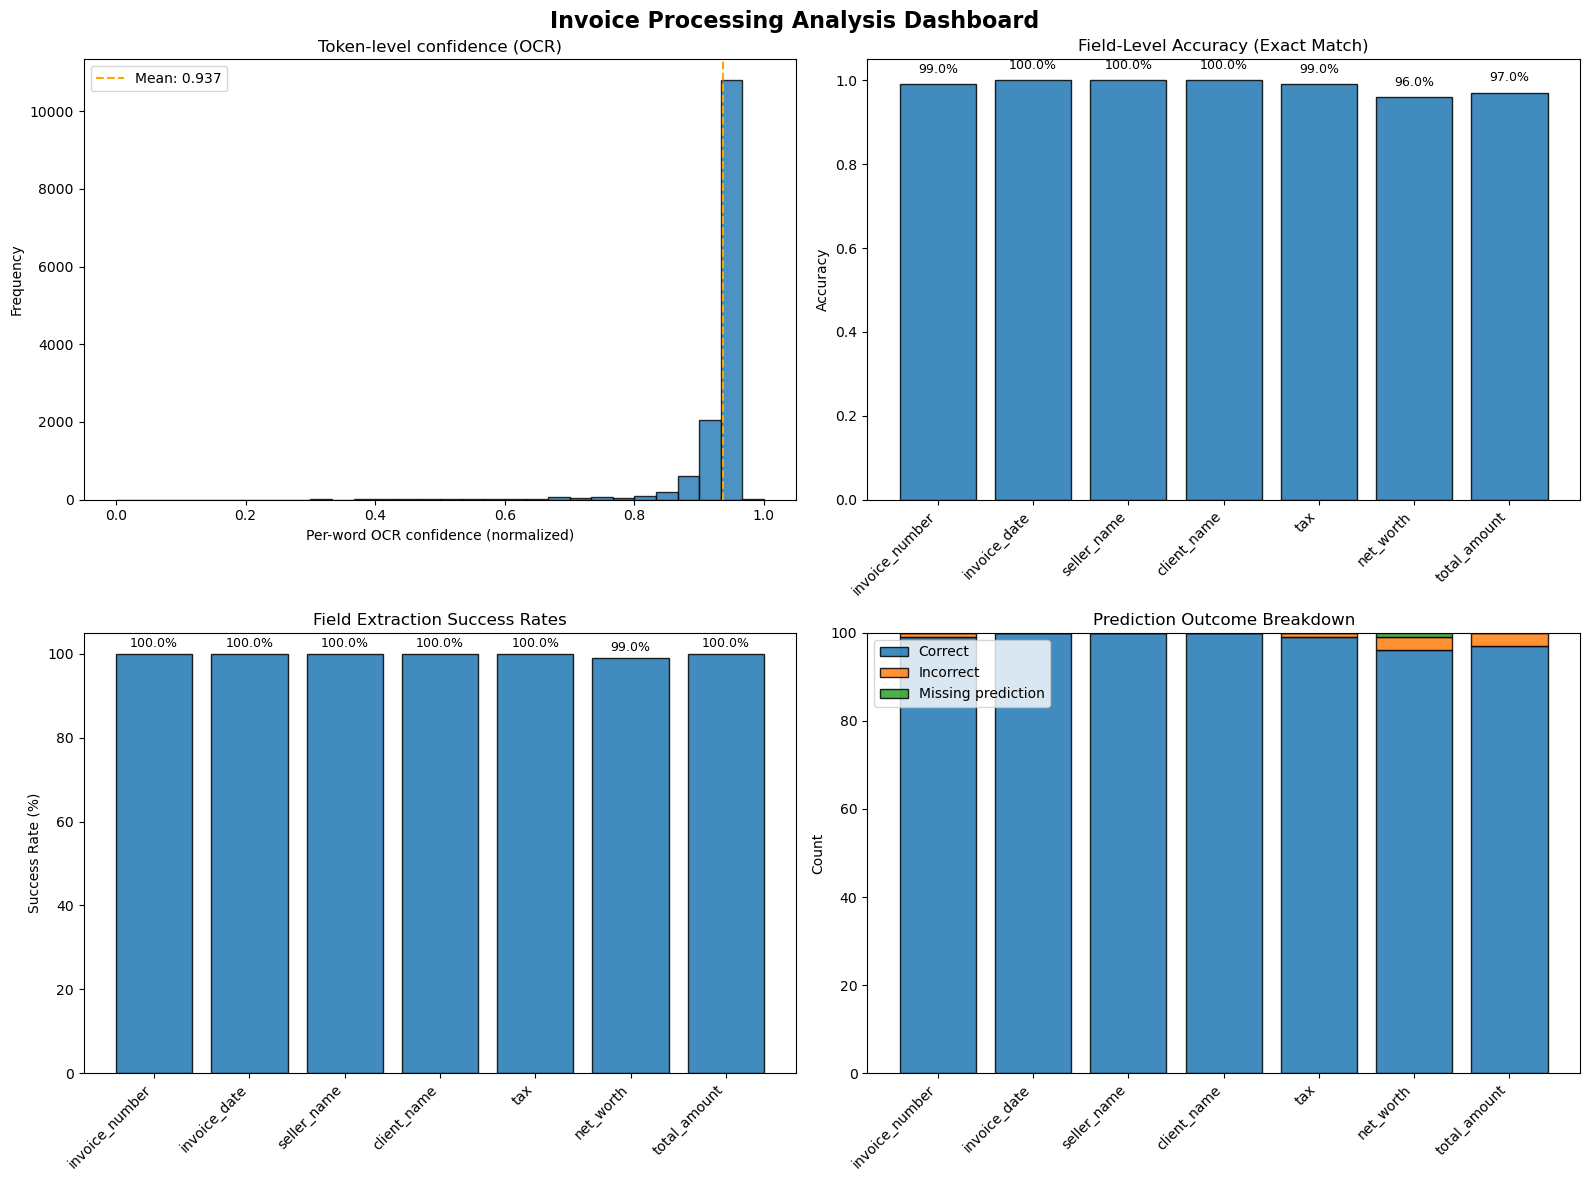


Sample 1: processed_batch1-0858.jpg
Total words detected: 204
Average confidence: 93.417

Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample extracted text (first 10 words):
  Invoice no: 59506452 Date of issue: 11/20/2017 Seller: Client: Alexander,...


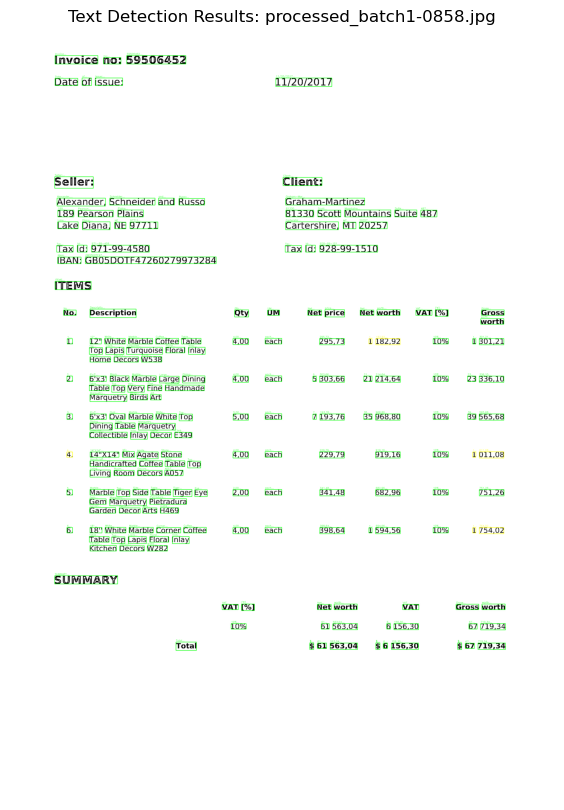


Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample 2: processed_batch1-0935.jpg
Total words detected: 124
Average confidence: 94.435

Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample extracted text (first 10 words):
  Invoice no: 90172850 Date of issue: 09/22/2012 Seller: Client: Johnson,...


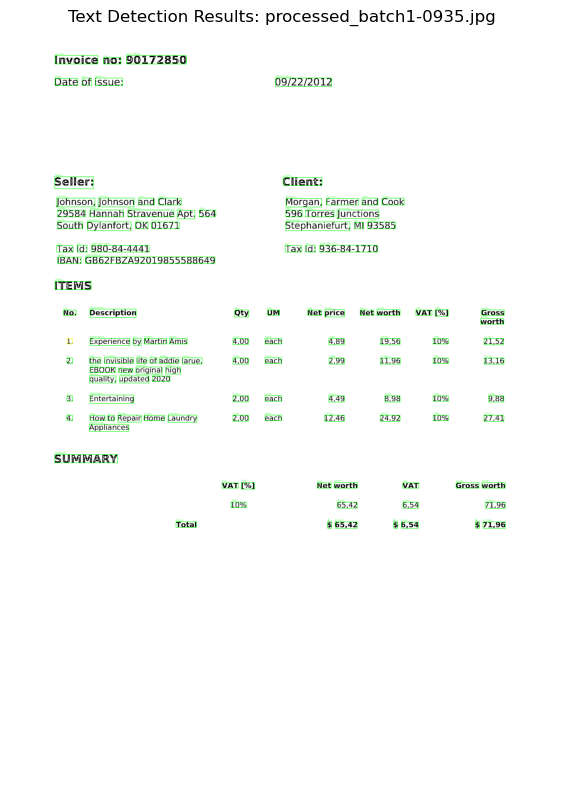


Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample 3: processed_batch1-0412.jpg
Total words detected: 116
Average confidence: 93.129

Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86

Sample extracted text (first 10 words):
  Invoice no: 60866416 Date of issue: 02/17/2021 Seller: Client: Parker,...


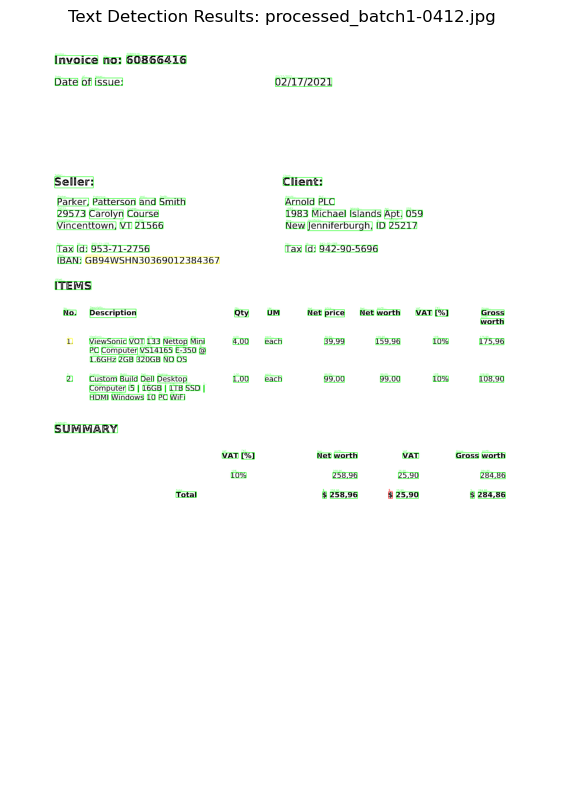


Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86


In [10]:
dashboard_stats = create_analysis_dashboard(
    ocr_text_detector.full_results,
    metrics_df=metrics_df,
    fields=[
        "invoice_number",
        "invoice_date",
        "seller_name",
        "client_name",
        "tax",
        "net_worth",
        "total_amount",
    ],
    panel_model="ocr",
)

visualize_sample_results(
    ocr_text_detector.full_results,
    visualize_text_fn=ocr_text_detector.visualize_text_extraction,
    n_samples=3,
)